# Compare pool metrics
Load all metrics parquets from `artifacts/` and compare MAE, RMSE, MAPE across models (baseline, lstm, xgboost, lightgbm, elasticnet, xgb_lstm_stack, chronos).

In [1]:
from pathlib import Path
import pandas as pd

ARTIFACTS_DIR = Path.cwd() / "artifacts"

files = {
    "baseline": "metrics_baseline_pool.parquet",
    "lstm": "metrics_lstm_pool.parquet",
    "xgboost": "metrics_xgboost_pool.parquet",
    "lightgbm": "metrics_lightgbm_pool.parquet",
    "elasticnet": "metrics_elasticnet_pool.parquet",
    "xgb_lstm_stack": "metrics_xgb_lstm_stack_pool.parquet",
    "chronos": "metrics_chronos_pool.parquet",
}
dfs = []
for name, f in files.items():
    p = ARTIFACTS_DIR / f
    if p.exists():
        df = pd.read_parquet(p)
        dfs.append(df)
    else:
        print(f"Missing: {p}")

if not dfs:
    raise SystemExit("No metrics files found. Run 01–04 pool notebooks first.")
all_metrics = pd.concat(dfs, ignore_index=True)
print("Overall :")
overall = all_metrics[all_metrics["symbol"] == "overall"].sort_values('MAE')
overall

Overall :


,model,symbol,MAE,RMSE,MAPE_%
76,chronos,overall,11.112044,14.951325,4.349936
21,lstm,overall,11.131069,14.906411,4.406365
43,lightgbm,overall,11.187229,15.427596,4.268077
54,elasticnet,overall,11.262520,15.554825,4.277606
65,xgb_lstm_stack,overall,11.269947,15.557493,4.280586
32,xgboost,overall,11.311873,15.539589,4.302133
10,baseline,overall,11.755865,15.041273,4.601217


In [2]:
all_metrics

,model,symbol,MAE,RMSE,MAPE_%
0,baseline,AAPL,10.576515,12.508965,3.993837
1,baseline,MSFT,20.227439,23.984635,4.761016
2,baseline,GOOGL,14.949737,16.611171,4.633056
3,baseline,AMZN,13.883547,16.152378,6.272374
4,baseline,JPM,11.060196,12.891812,3.517454
...,...,...,...,...,...
72,chronos,WMT,4.884244,5.593501,3.968512
73,chronos,SPY,6.521761,7.735084,0.948906
74,chronos,XOM,8.155644,9.521872,5.866924
75,chronos,NVDA,7.434028,8.641304,4.034546


In [3]:
# Pivot: rows = symbol (or overall), columns = model, values = MAE / RMSE / MAPE_%
for metric in ["MAE", "RMSE", "MAPE_%"]:
    if metric not in all_metrics.columns:
        continue
    pt = all_metrics.pivot_table(index="symbol", columns="model", values=metric)
    print(f"\n--- {metric} ---")
    print(pt.to_string())
    print()


--- MAE ---
model     baseline    chronos  elasticnet   lightgbm       lstm  xgb_lstm_stack    xgboost
symbol                                                                                    
AAPL     10.576515  11.120810   10.885479  10.855679  11.089841       10.847026  11.025909
AMZN     13.883547  13.742466   13.809339  13.781546  15.033721       13.815278  13.800689
GOOGL    14.949737  13.156044   13.294422  13.298114  13.851236       13.383608  13.597635
JNJ      12.283744  11.570445    9.414339   9.582916  10.833193        9.427829   9.586452
JPM      11.060196  10.471748   10.947172  10.752822  11.089579       10.898382  10.633022
MSFT     20.227439  24.063253   26.718009  26.519576  21.391627       26.644604  26.574246
NVDA      7.207861   7.434028    6.766041   6.657137   6.179744        6.751262   6.763804
SPY      11.581101   6.521761    8.385210   7.900878   7.382664        8.474664   8.521104
WMT       5.970048   4.884244    4.864321   4.945941   6.012216        4.8918

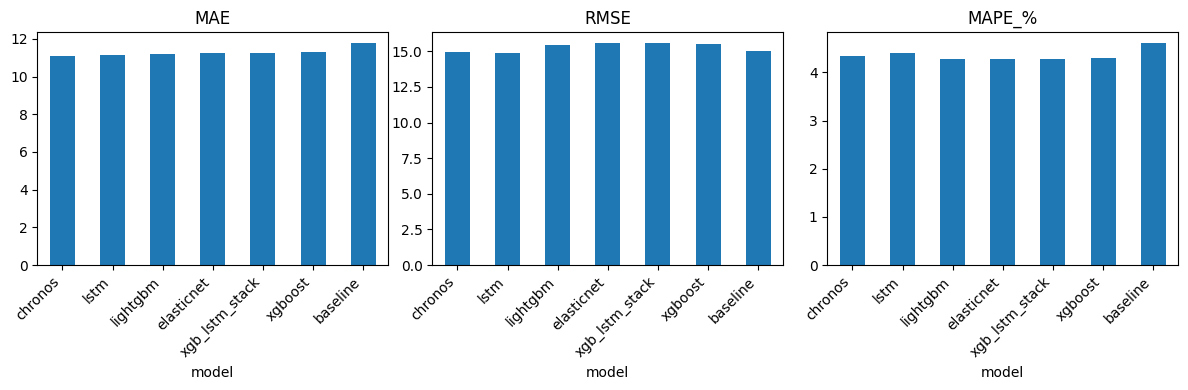

In [4]:
# Overall row only: bar comparison

if overall.empty:
    overall = all_metrics.groupby("model").agg({"MAE": "mean", "RMSE": "mean", "MAPE_%": "mean"}).reset_index()

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, ["MAE", "RMSE", "MAPE_%"]):
    if col in overall.columns:
        overall.plot(x="model", y=col, kind="bar", ax=ax, legend=False)
        ax.set_title(col)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()